# 노트북 1 — 데이터 준비 (PhysioNet EEG Motor Imagery)

**EEG Resonate Encoding SNN 프로젝트** · 노트북 1

PhysioNet EEG Motor Movement/Imagery 데이터셋에서 왼손·오른손 주먹 씁기 심상 구간을 내려받아
전처리하고, 이후 노트북들이 공통으로 쓸 `.npz` 파일로 저장한다.

### 학습 목표
- `mne.datasets.eegbci`로 피험자별 EDF 데이터를 내려받는다.
- 9채널만 골라 1–45 Hz 대역통과 → 128 Hz 리샘플 → 채널별 z-score를 적용한다.
- 큐 후 0.5–2.0 s 구간을 에폭으로 잘라 (시행, 채널, 시간) 배열을 만든다.
- 피험자별 시행 수와 클래스 균형을 확인하고 `.npz`로 저장한다.


## 1. 설치와 임포트

In [1]:
%pip install -q mne

import os
import numpy as np
import mne
from mne.datasets import eegbci
from mne.io import concatenate_raws, read_raw_edf
from mne import Epochs, events_from_annotations
import matplotlib.pyplot as plt
import koreanize_matplotlib          # 그래프 한글 폰트

np.random.seed(0)                    # 재현성
mne.set_log_level('WARNING')         # MNE 로그 출력 억제

print('mne 버전:', mne.__version__)


Note: you may need to restart the kernel to use updated packages.


mne 버전: 1.12.1


## 2. 파라미터 설정

실험 설계(CLAUDE.md 3, 4절)에 따른 상수들이다.

In [2]:
SUBJECTS = range(1, 6)                                                   # 피험자 5명 (S1~S5)
RUNS = [4, 8, 12]                                                        # 왼손/오른손 주먹 씁기 심상 러닝
CHANNELS = ['FC3', 'FCz', 'FC4', 'C3', 'Cz', 'C4', 'CP3', 'CPz', 'CP4']  # 9채널
L_FREQ, H_FREQ = 1.0, 45.0                                               # 대역통과 범위 [Hz]
FS = 128                                                                 # 리샘플 주파수 [Hz]
TMIN, TMAX = 0.5, 2.0                                                    # 큐 후 에폭 구간 [s]
NUM_STEPS = 192                                                          # 에폭 시간 스텝 수
DATA_DIR = '../data/raw'                                                 # EDF 원본 저장 경로
OUT_PATH = '../data/processed/eeg_epochs.npz'                            # 전처리 결과 저장 경로


## 3. 피험자별 전처리 함수

`eegbci`로 원본을 불러와 채널명을 표준화하고, 9채널만 골라 대역통과·리샘플·z-score를 적용한 뒤
큐 후 0.5–2.0 s 구간을 에폭으로 잘라낸다. T1=왼손, T2=오른손 이벤트만 사용한다(T0=휴식 제외).

In [3]:
def load_subject(subject_id):
    raw_fnames = eegbci.load_data(subject_id, RUNS, path=DATA_DIR, update_path=True)  # EDF 내려받기
    raws = [read_raw_edf(f, preload=True) for f in raw_fnames]
    raw = concatenate_raws(raws)                      # 3개 런을 하나로 이어붙임

    eegbci.standardize(raw)                           # 채널명 표준화 (Fc3. → FC3)
    raw.set_montage('standard_1005')                  # 좌표계 설정
    raw.pick(CHANNELS)                                 # 9채널만 선택

    raw.filter(L_FREQ, H_FREQ, fir_design='firwin')    # 1-45 Hz 대역통과
    raw.resample(FS)                                   # 128 Hz 리샘플
    raw.apply_function(
        lambda x: (x - x.mean()) / x.std(),
        channel_wise=True
    )                                                   # 채널별 z-score

    events, event_id_all = events_from_annotations(raw)
    event_id = {name: event_id_all[name] for name in ('T1', 'T2')}   # T1=왼손, T2=오른손

    epochs = Epochs(
        raw, events, event_id=event_id,
        tmin=TMIN, tmax=TMAX, baseline=None, preload=True
    )

    data = epochs.get_data()[:, :, :NUM_STEPS].astype(np.float32)      # (시행, 채널, 시간)
    labels = (epochs.events[:, 2] == event_id['T2']).astype(np.int64)  # 오른손=1, 왼손=0

    return data, labels


## 4. 전체 피험자 처리

In [4]:
X_list, y_list, subject_id_list = [], [], []

for subject_id in SUBJECTS:
    data, labels = load_subject(subject_id)
    X_list.append(data)
    y_list.append(labels)
    subject_id_list.append(np.full(labels.shape, subject_id, dtype=np.int64))
    print(f'S{subject_id:02d} 시행 수: {len(labels)} | 오른손 비율: {labels.mean():.2f}')

X = np.concatenate(X_list, axis=0)                    # (전체 시행, 9, 192)
y = np.concatenate(y_list, axis=0)
subject_ids = np.concatenate(subject_id_list, axis=0)

print('전체 데이터 형태:', X.shape)


S01 시행 수: 45 | 오른손 비율: 0.49


S02 시행 수: 45 | 오른손 비율: 0.49


S03 시행 수: 45 | 오른손 비율: 0.49


S04 시행 수: 45 | 오른손 비율: 0.49


S05 시행 수: 45 | 오른손 비율: 0.53
전체 데이터 형태: (225, 9, 192)


## 5. 저장

다음 노트북들이 이 파일 하나만 불러오면 되도록 `.npz`로 저장한다.

In [5]:
os.makedirs(os.path.dirname(OUT_PATH), exist_ok=True)   # 저장 폴더 생성

np.savez(
    OUT_PATH,
    X=X, y=y, subject_ids=subject_ids,
    channels=np.array(CHANNELS), fs=FS
)
print('저장 완료:', OUT_PATH)


저장 완료: ../data/processed/eeg_epochs.npz


## 6. 저장 확인 — 시행 수·클래스 균형

피험자당 약 45시행, 두 클래스 개수가 비슷한지 확인한다.

In [6]:
for subject_id in SUBJECTS:
    mask = subject_ids == subject_id                     # 불리언 마스크로 피험자 선택
    n_trials = mask.sum()
    n_right = y[mask].sum()
    n_left = n_trials - n_right
    print(f'S{subject_id:02d} | 총 {n_trials}시행 | 왼손 {n_left} | 오른손 {n_right}')


S01 | 총 45시행 | 왼손 23 | 오른손 22
S02 | 총 45시행 | 왼손 23 | 오른손 22
S03 | 총 45시행 | 왼손 23 | 오른손 22
S04 | 총 45시행 | 왼손 23 | 오른손 22
S05 | 총 45시행 | 왼손 21 | 오른손 24


## 7. 시각화 — 예시 에폭 파형

C3 채널에서 왼손·오른손 각각 예시 에폭 하나씩을 겹쳐 그려 데이터가 정상적으로 들어왔는지 눈으로 확인한다.

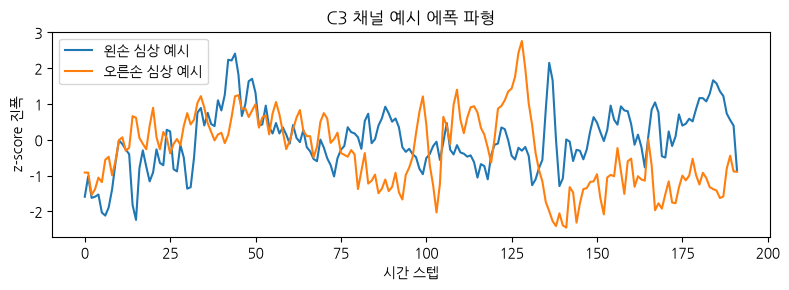

In [7]:
c3_idx = CHANNELS.index('C3')
left_idx = np.where(y == 0)[0][0]
right_idx = np.where(y == 1)[0][0]

plt.figure(figsize=(8, 3))
plt.plot(X[left_idx, c3_idx], color='tab:blue', label='왼손 심상 예시')
plt.plot(X[right_idx, c3_idx], color='tab:orange', label='오른손 심상 예시')
plt.xlabel('시간 스텝'); plt.ylabel('z-score 진폭')
plt.title('C3 채널 예시 에폭 파형')
plt.legend(); plt.tight_layout(); plt.show()


## 정리

- `mne.datasets.eegbci`로 피험자 5명(S1~S5)의 왼손/오른손 주먹 씁기 심상 데이터를 내려받았다.
- 9채널 → 1–45 Hz 대역통과 → 128 Hz 리샘플 → 채널별 z-score 순으로 전처리했다.
- 큐 후 0.5–2.0 s 구간을 잘라 (시행, 9, 192) 형태의 에폭 배열을 만들었다.
- 피험자당 약 45시행, 두 클래스 비율이 비슷함을 확인하고 `../data/processed/eeg_epochs.npz`로 저장했다.

다음 노트북(02_sanity_check)에서는 이 데이터로 SNN 없이 로지스틱 회귀 베이스라인을 먼저 통과시킨다.